## Download data

In [1]:
import pandas as pd
import yfinance as yf
import datetime as dt
import matplotlib.pyplot as plt
import numpy as np

FINAL_TICKERS = ["AMH", "AVB", "CPT", "ELS", "EQR", "IRT", "MAA", "SUI", "UDR", "UMH"]

end_date = dt.datetime.now().strftime('%Y-%m-%d')
start_date = (pd.to_datetime(end_date) - pd.DateOffset(365*12)).strftime('%Y-%m-%d')
df = yf.download(FINAL_TICKERS, start=start_date, end=end_date, auto_adjust=True)['Close']


df = df.dropna(axis=1)
df

[*********************100%***********************]  10 of 10 completed


Ticker,AMH,AVB,CPT,ELS,EQR,IRT,MAA,SUI,UDR,UMH
Date,,,,,,,,,,
2014-07-21,15.044566,98.082481,45.834122,16.566376,36.135635,5.071482,47.590141,35.153805,18.691704,5.198369
2014-07-22,15.011972,98.149536,45.909435,16.367014,36.409302,5.091973,47.635536,34.963612,18.763720,5.214106
2014-07-23,14.995667,97.324783,46.173019,16.511000,36.481915,5.097096,47.972618,35.140209,18.750633,5.235087
2014-07-24,15.085323,100.013664,46.235775,16.463003,36.772343,5.086852,48.218960,35.541000,18.875019,5.166894
2014-07-25,15.020115,99.229118,45.827835,16.522079,36.213837,4.953659,48.102272,35.656490,18.737532,5.124932
...,...,...,...,...,...,...,...,...,...,...
2026-07-10,33.270000,191.839996,112.959999,63.470001,68.690002,16.740000,133.702026,118.879997,39.730000,15.280000
2026-07-13,33.799999,194.529999,114.190002,64.980003,69.720001,16.840000,134.334702,120.800003,40.180000,15.410000
2026-07-14,33.860001,191.750000,112.980003,64.080002,68.720001,16.549999,132.149994,119.779999,39.970001,15.370000


## The Strategy

--- Strategy ---
Total return: 179.12%
Sharpe ratio: 1.26
Max drawdown: -8.56%
--- Benchmark ---
Total return: 194.11%
Sharpe ratio: 0.52
Max drawdown: -39.51%


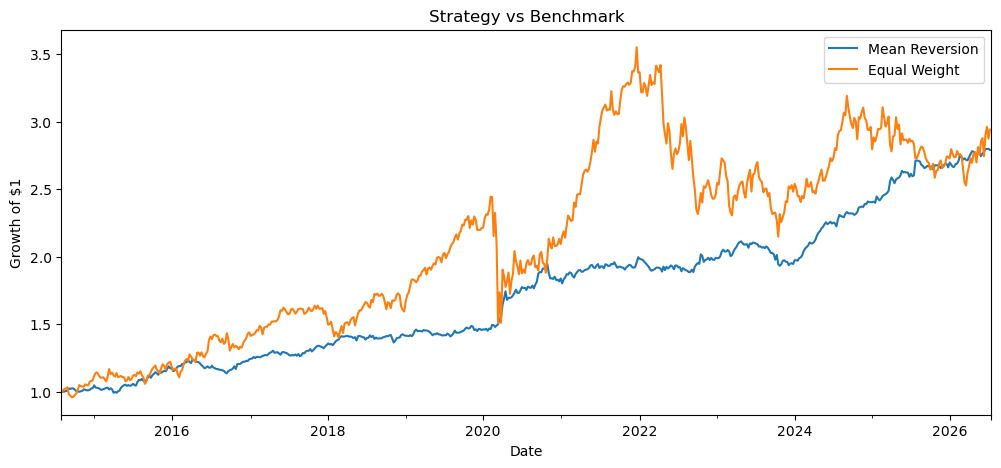

In [2]:
from backtest import run_backtest, run_benchmark, print_stats

end = df.index.max()
start = df.index.min()

strategy = run_backtest(df, start_date=start, end_date=end, cost_bps=0)
benchmark = run_benchmark(df, start_date=start, end_date=end)

print("--- Strategy ---")
print_stats(strategy["stats"])

print("--- Benchmark ---")
print_stats(benchmark["stats"])


equity = strategy["equity"]
cluster_equity = benchmark["equity"]

plt.figure(figsize=(12, 5))
(equity / equity.iloc[0]).plot(label="Mean Reversion")
(cluster_equity / cluster_equity.iloc[0]).plot(label="Equal Weight")
plt.legend()
plt.ylabel("Growth of $1")
plt.title("Strategy vs Benchmark")
plt.show()

## Label outcome
The strategy predicts long/short positions for each stock for each week. Based on the outcome of the NEXT week (after the prediction), we label each position as successful (1) or unsuccessful (0). 
- For a stock in a long position, success = price goes up the next week
- For a stock in a short position, success = price goes down the next week

In [3]:
strategy['dollar_positions'].head(10)

Ticker,AMH,AVB,CPT,ELS,EQR,IRT,MAA,SUI,UDR,UMH
Date,,,,,,,,,,
2014-08-01,1063.417866,-903.785766,-107.467327,544.051016,127.828967,-1201.847405,3264.702151,-669.184471,-1255.494010,-862.221021
2014-08-08,3185.933496,204.472759,323.678448,829.689139,-514.337095,240.364445,215.861713,-1329.608900,-431.486649,-2724.567355
2014-08-15,1912.150753,253.774972,-656.865408,-1088.677367,-223.895918,-2860.886794,411.155947,-169.674513,571.697584,1851.220744
2014-08-22,-1762.048646,-768.729770,1087.082483,540.931547,-22.685185,-1751.250402,129.519718,2873.422321,369.043930,-695.285997
2014-08-29,2374.702902,157.333470,-1061.487896,-1639.966838,526.536407,1661.439444,-699.862791,279.987776,-443.114276,-1155.568199
2014-09-05,-1484.447624,-671.519746,-196.568701,-411.275723,-760.714915,3464.167911,-203.358621,-483.209937,-788.904733,1535.832089
2014-09-12,-1592.608326,1222.756054,458.309062,160.101120,1145.330192,-2950.850302,740.837221,386.052037,886.614315,-456.541371
2014-09-19,607.221342,-813.426347,1585.159022,1425.368032,-536.330594,-1205.010621,737.006695,-2445.232438,602.394045,42.850864
2014-09-26,541.623260,911.239546,-1029.758595,-2271.523557,-322.765493,1552.752328,31.123884,-1375.952355,292.053951,1671.207031


In [4]:
from backtest import prepare_weekly_data
_, weekly_simple_returns = prepare_weekly_data(df)
weekly_simple_returns.head(10)

Ticker,AMH,AVB,CPT,ELS,EQR,IRT,MAA,SUI,UDR,UMH
Date,,,,,,,,,,
2014-08-01,-0.024959,0.004731,-0.007395,-0.017207,-0.010950,0.009307,-0.057142,0.001143,0.010133,0.004094
2014-08-08,-0.018364,0.007533,0.006484,0.002046,0.013878,0.007217,0.007433,0.021123,0.013144,0.033639
2014-08-15,-0.000567,0.007744,0.012337,0.014522,0.010151,0.023541,0.006952,0.009877,0.006145,-0.000263
2014-08-22,0.026092,0.017687,0.002167,0.006710,0.011419,0.026000,0.010145,-0.012548,0.008144,0.017068
2014-08-29,-0.011608,0.003059,0.011214,0.015108,0.000602,-0.006914,0.008788,0.002242,0.007069,0.011847
2014-09-05,0.015660,0.011421,0.008953,0.010068,0.011885,-0.009872,0.008988,0.010442,0.012032,0.000000
2014-09-12,-0.025925,-0.069870,-0.058138,-0.053521,-0.068689,-0.003988,-0.062491,-0.057021,-0.064730,-0.043903
2014-09-19,-0.017007,0.000207,-0.028684,-0.026786,-0.003174,0.005005,-0.018565,0.020353,-0.016949,-0.010204
2014-09-26,-0.016148,-0.019308,-0.002599,0.008239,-0.008718,-0.024768,-0.011767,0.000411,-0.014008,-0.025773


In [5]:
_, weekly_simple_returns = prepare_weekly_data(df)

forward_returns = weekly_simple_returns.shift(-1)
forward_returns

trade_result = strategy['dollar_positions'] * forward_returns

# Label each trade as successful (1) or unsuccessful (0)
label = (trade_result > 0).astype(int)

## Engineer Features
ChatGPT suggested these 9 features:
- `side`: Whether the proposed position is long or short.
- `abs_base_weight`: How large the position is compared with the £10,000 portfolio.
- `residual_zscore`: How unusual the stock’s movement is compared with the other stocks that week.
- `residual_lag1`: The stock’s residual from the previous week.
- `residual_4w_sum`: The total residual over the last four weeks.
- `residual_vol_4w`: How much the residual moved around during the last four weeks.
- `stock_vol_4w`: How much the stock’s weekly returns moved around during the last four weeks.
- `cluster_return`: How the whole group of REIT stocks performed this week.
- `cluster_vol_4w`: How volatile the whole group has been over the last four weeks.

I will start with these features for now and make necessary edits later.

In [6]:
I = 10_000

# weekly data (same as backtest)
weekly_log_returns, weekly_simple_returns = prepare_weekly_data(df)
forward_returns = weekly_simple_returns.shift(-1)

positions = strategy["dollar_positions"]

# residuals for each stock
cluster_return = weekly_log_returns.mean(axis=1) # mean cluster return
residuals = weekly_log_returns.sub(cluster_return, axis=0)

# residual z-score within each week (across tickers)
# z-score is how many stds away from mean, (x - mean) / std
residual_zscore = residuals.sub(residuals.mean(axis=1), axis=0).div(
    residuals.std(axis=1), axis=0
)

# align everything to positions' index
common_idx = positions.index.intersection(weekly_log_returns.index).intersection(
    forward_returns.dropna(how="all").index
)

positions = positions.loc[common_idx]
residuals = residuals.loc[common_idx]
residual_zscore = residual_zscore.loc[common_idx]
weekly_simple_returns = weekly_simple_returns.loc[common_idx]
weekly_log_returns = weekly_log_returns.loc[common_idx]
cluster_return = cluster_return.loc[common_idx]
forward_returns = forward_returns.loc[common_idx]

# feature calculation, all are pretty self explanatory
side = np.sign(positions)
abs_base_weight = positions.abs() / I

residual_lag1 = residuals.shift(1)
residual_4w_sum = residuals.rolling(4).sum()
residual_vol_4w = residuals.rolling(4).std()
stock_vol_4w = weekly_simple_returns.rolling(4).std()
cluster_vol_4w = cluster_return.rolling(4).std()

# Current residual relative to the stock's previous 26 weeks
residual_history = residuals.shift(1)

residual_mean_26w = residual_history.rolling(
    window=26,
    min_periods=26,
).mean()

residual_std_26w = residual_history.rolling(
    window=26,
    min_periods=26,
).std()

residual_ts_zscore_26w = (
    residuals - residual_mean_26w
).div(
    residual_std_26w.replace(0, np.nan)
)

# Lag-1 autocorrelation calculated using the previous 26 weeks
residual_autocorr_26w = (
    residuals.shift(1)
    .rolling(
        window=26,
        min_periods=26,
    )
    .apply(
        lambda window: window.autocorr(lag=1),
        raw=False,
    )
)

number_of_stocks = weekly_log_returns.shape[1]

# Sum of every stock's return during each week
cluster_return_sum = weekly_log_returns.sum(
    axis=1,
    skipna=False,
)

# For each stock, subtract its return before calculating the peer average
leave_one_out_cluster_returns = (
    weekly_log_returns.rsub(
        cluster_return_sum,
        axis=0,
    )
    / (number_of_stocks - 1)
)

stock_cluster_corr_26w = (
    weekly_log_returns.shift(1)
    .rolling(
        window=26,
        min_periods=26,
    )
    .corr(
        leave_one_out_cluster_returns.shift(1)
    )
)

# Cross-sectional spread of stock residuals during each week
residual_dispersion = residuals.std(axis=1)

# stack into long table: one row = one week and one ticker
features = pd.concat(
    {
        "base_position": positions,
        "side": side,
        "abs_base_weight": abs_base_weight,
        "residual_zscore": residual_zscore,
        "residual_ts_zscore_26w": residual_ts_zscore_26w,
        "residual_autocorr_26w": residual_autocorr_26w,
        "residual_lag1": residual_lag1,
        "residual_4w_sum": residual_4w_sum,
        "residual_vol_4w": residual_vol_4w,
        "stock_vol_4w": stock_vol_4w,
        "stock_cluster_corr_26w": stock_cluster_corr_26w,
        "label": label,
    },
    axis=1,
).stack(level=1)
features.index.names = ["date", "ticker"]
# features = features.reset_index()

# cluster_return / cluster_vol are the same for all tickers on a date
features = features.drop(columns=["cluster_return"], errors="ignore")
features = features.reset_index()
# features["cluster_return"] = features["date"].map(cluster_return)
# features["cluster_vol_4w"] = features["date"].map(cluster_vol_4w)
# features["residual_dispersion"] = features["date"].map(
#     residual_dispersion
# )

# drop early rows with NaNs from rolling windows / last week with no forward return
features = features.dropna().reset_index(drop=True)

features

,date,ticker,base_position,side,abs_base_weight,residual_zscore,residual_ts_zscore_26w,residual_autocorr_26w,residual_lag1,residual_4w_sum,residual_vol_4w,stock_vol_4w,stock_cluster_corr_26w,label
0,2015-01-30,AMH,708.292470,1.0,0.070829,-0.599234,-0.146727,0.073523,-0.005822,-0.075122,0.013075,0.014170,0.550019,0
1,2015-01-30,AVB,1129.702826,1.0,0.112970,-0.955759,-1.903891,-0.294964,-0.005081,0.006628,0.014516,0.035344,0.860645,0
2,2015-01-30,CPT,1136.655335,1.0,0.113666,-0.961641,-1.626835,0.064771,0.000705,-0.012124,0.008486,0.028531,0.908358,0
3,2015-01-30,ELS,112.594024,1.0,0.011259,-0.095258,-0.443906,-0.024274,-0.012816,0.008506,0.011836,0.030597,0.822975,0
4,2015-01-30,EQR,712.364810,1.0,0.071236,-0.602680,-1.445978,0.041111,0.001076,0.019873,0.011854,0.033184,0.897326,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5975,2026-07-10,IRT,379.807233,1.0,0.037981,-0.319858,-0.110049,-0.138109,0.004135,0.004938,0.015765,0.063536,0.880633,1
5976,2026-07-10,MAA,1784.807011,1.0,0.178481,-1.503090,-2.053913,0.004641,-0.010007,-0.024970,0.010701,0.052771,0.945435,1
5977,2026-07-10,SUI,794.028744,1.0,0.079403,-0.668698,-0.310815,-0.005582,0.008321,-0.054521,0.017656,0.047118,0.638864,1
5978,2026-07-10,UDR,290.422167,1.0,0.029042,-0.244581,-0.483660,-0.063114,0.006986,0.010216,0.004905,0.052154,0.902820,1


## Train the model

We will train 3 models: logistic regression, random forest and xgBoost

### 1. Data Preparation

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

scaler = StandardScaler()

# Split using complete weekly dates
unique_dates = np.sort(features["date"].unique())

validation_weeks = 2 * 52
test_weeks = 2 * 52

test_dates = unique_dates[-test_weeks:]
validation_dates = unique_dates[
    -(test_weeks + validation_weeks + 1):-(test_weeks + 1)
]
training_dates = unique_dates[
    -(test_weeks + validation_weeks + 2 + 52 * 4):-(test_weeks + validation_weeks + 2)
]

training_set = features[features["date"].isin(training_dates)].copy()
validation_set = features[features["date"].isin(validation_dates)].copy()
test_set = features[features["date"].isin(test_dates)].copy()

for name, dataset in [
    ("Training", training_set),
    ("Validation", validation_set),
    ("Test", test_set),
]:
    print(
        f"{name}:",
        dataset["date"].min().date(),
        "to",
        dataset["date"].max().date(),
        "| weeks:",
        dataset["date"].nunique(),
        "| rows:",
        len(dataset),
        "| profitable:",
        f"{dataset['label'].mean():.3f}",
    )

X_train, y_train = training_set.drop(columns=["label", "date", "ticker", "base_position"]), training_set["label"]
X_validation, y_validation = validation_set.drop(columns=["label", "date", "ticker", "base_position"]), validation_set["label"]
X_test, y_test = test_set.drop(columns=["label", "date", "ticker", "base_position"]), test_set["label"]


Training: 2018-07-13 to 2022-07-01 | weeks: 208 | rows: 2080 | profitable: 0.512
Validation: 2022-07-15 to 2024-07-05 | weeks: 104 | rows: 1040 | profitable: 0.499
Test: 2024-07-19 to 2026-07-10 | weeks: 104 | rows: 1040 | profitable: 0.522


### 2. Logistic Regression

In [8]:
# Train the model on the training set
logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        random_state=2,
        max_iter=1000,
    ))
])

logistic_model.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](10,)","['side','abs_base_weight','residual_zscore',...,'residual_vol_4w', 'stock_vol_4w','stock_cluster_corr_26w']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [9]:
# Evaluate on both training and validation data
logistic_train_pred = logistic_model.predict(X_train)
logistic_val_pred = logistic_model.predict(X_validation)

metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
train_scores = [
    accuracy_score(y_train, logistic_train_pred),
    precision_score(y_train, logistic_train_pred),
    recall_score(y_train, logistic_train_pred),
    f1_score(y_train, logistic_train_pred)
]

val_scores = [
    accuracy_score(y_validation, logistic_val_pred),
    precision_score(y_validation, logistic_val_pred),
    recall_score(y_validation, logistic_val_pred),
    f1_score(y_validation, logistic_val_pred)
]

logistic_results_df = pd.DataFrame({
    'Training': train_scores,
    'Validation': val_scores
}, index=metrics)

logistic_results_df

,Training,Validation
Accuracy,0.581250,0.503846
Precision,0.589368,0.502752
Recall,0.603189,0.527938
F1 Score,0.596198,0.515038


### 3. Random Forest

Accuracy: 0.4980769230769231
Precision: 0.497131931166348
Recall: 0.5009633911368016
F1: 0.4990403071017274
AUC: 0.5004530342198011


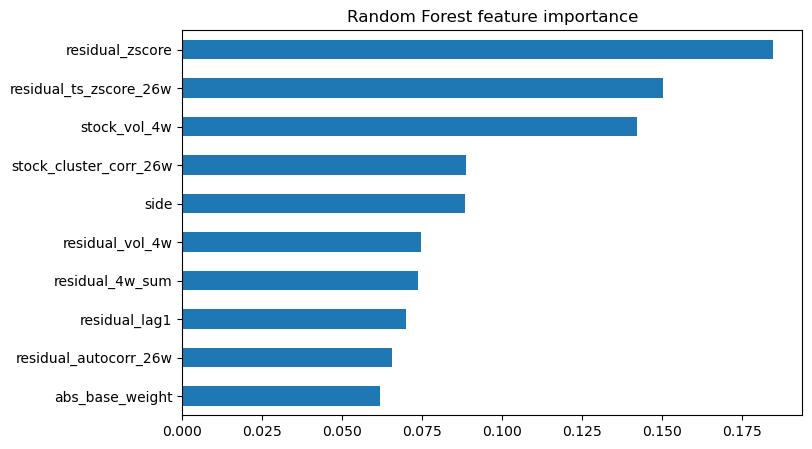

In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

rf = RandomForestClassifier(
    n_estimators=10000,
    max_depth=4,
    min_samples_leaf=30,
    max_features="sqrt",
    random_state=1,
    n_jobs=-1,
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_validation)
y_prob = rf.predict_proba(X_validation)[:, 1]

print("Accuracy:", accuracy_score(y_validation, y_pred))
print("Precision:", precision_score(y_validation, y_pred))
print("Recall:", recall_score(y_validation, y_pred))
print("F1:", f1_score(y_validation, y_pred))
print("AUC:", roc_auc_score(y_validation, y_prob))

importances = pd.Series(rf.feature_importances_, index=X_train.columns)
importances.sort_values().plot(kind="barh", figsize=(8, 5))
plt.title("Random Forest feature importance")
plt.show()

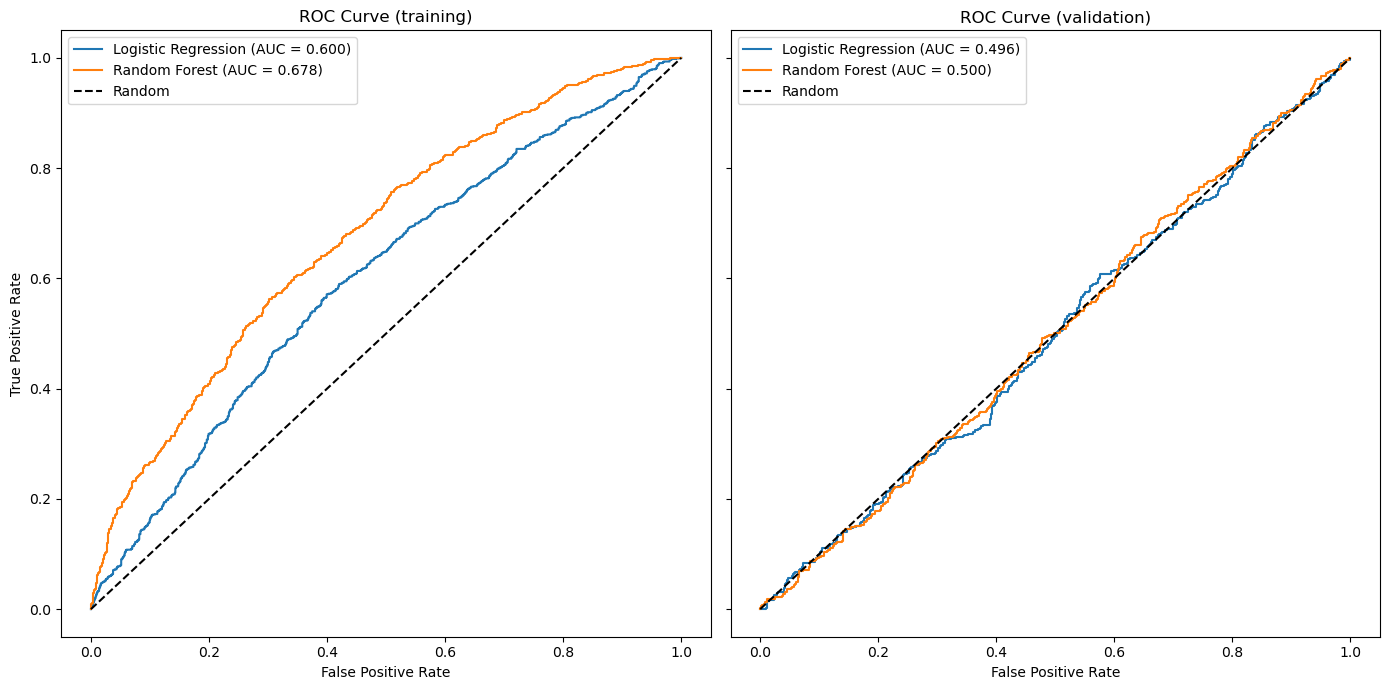

In [11]:
from sklearn.metrics import roc_curve, roc_auc_score

# Probabilities for training and validation sets
lr_prob_val = logistic_model.predict_proba(X_validation)[:, 1]
rf_prob_val = rf.predict_proba(X_validation)[:, 1]
lr_prob_train = logistic_model.predict_proba(X_train)[:, 1]
rf_prob_train = rf.predict_proba(X_train)[:, 1]

# ROC curve for the training set
lr_fpr_train, lr_tpr_train, _ = roc_curve(y_train, lr_prob_train)
rf_fpr_train, rf_tpr_train, _ = roc_curve(y_train, rf_prob_train)

lr_auc_train = roc_auc_score(y_train, lr_prob_train)
rf_auc_train = roc_auc_score(y_train, rf_prob_train)

# ROC curve for the validation set
lr_fpr_val, lr_tpr_val, _ = roc_curve(y_validation, lr_prob_val)
rf_fpr_val, rf_tpr_val, _ = roc_curve(y_validation, rf_prob_val)

lr_auc_val = roc_auc_score(y_validation, lr_prob_val)
rf_auc_val = roc_auc_score(y_validation, rf_prob_val)

fig, axes = plt.subplots(1, 2, figsize=(14, 7), sharey=True)

# Plot ROC for training set (left)
axes[0].plot(lr_fpr_train, lr_tpr_train, label=f"Logistic Regression (AUC = {lr_auc_train:.3f})")
axes[0].plot(rf_fpr_train, rf_tpr_train, label=f"Random Forest (AUC = {rf_auc_train:.3f})")
axes[0].plot([0, 1], [0, 1], "k--", label="Random")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve (training)")
axes[0].legend()

# Plot ROC for validation set (right)
axes[1].plot(lr_fpr_val, lr_tpr_val, label=f"Logistic Regression (AUC = {lr_auc_val:.3f})")
axes[1].plot(rf_fpr_val, rf_tpr_val, label=f"Random Forest (AUC = {rf_auc_val:.3f})")
axes[1].plot([0, 1], [0, 1], "k--", label="Random")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_title("ROC Curve (validation)")
axes[1].legend()

plt.tight_layout()
plt.show()


##### 3. XGBoost

In [12]:
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
)

# A deliberately conservative first XGBoost model.
xgb_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",

    n_estimators=30000,
    learning_rate=0.01,
    max_depth=2,
    min_child_weight=20,

    subsample=0.80,
    colsample_bytree=0.80,

    reg_alpha=0.10,
    reg_lambda=2.00,

    random_state=1,
    n_jobs=-1,
)

# Train only on the chronological training period.
xgb_model.fit(X_train, y_train)

# Produce probabilities for the training and validation periods.
xgb_prob_train = xgb_model.predict_proba(X_train)[:, 1]
xgb_prob_val = xgb_model.predict_proba(X_validation)[:, 1]

# Convert validation probabilities into keep/skip predictions at 0.50.
xgb_pred_val = (xgb_prob_val >= 0.50).astype(int)

print("XGBoost results")
print("----------------")
print(f"Training ROC-AUC:   {roc_auc_score(y_train, xgb_prob_train):.4f}")
print(f"Validation ROC-AUC: {roc_auc_score(y_validation, xgb_prob_val):.4f}")
print(f"Validation accuracy:  {accuracy_score(y_validation, xgb_pred_val):.4f}")
print(f"Validation precision: {precision_score(y_validation, xgb_pred_val, zero_division=0):.4f}")
print(f"Validation recall:    {recall_score(y_validation, xgb_pred_val, zero_division=0):.4f}")
print(f"Validation F1:        {f1_score(y_validation, xgb_pred_val, zero_division=0):.4f}")
print(f"Average probability:  {xgb_prob_val.mean():.4f}")
print(f"Predicted keep rate:  {xgb_pred_val.mean():.4f}")

XGBoost results
----------------
Training ROC-AUC:   0.9620
Validation ROC-AUC: 0.5329
Validation accuracy:  0.5433
Validation precision: 0.5433
Validation recall:    0.5318
Validation F1:        0.5375
Average probability:  0.4932
Predicted keep rate:  0.4885


### 4. Backtest

In [13]:
from backtest import backtest_positions

thresholds = np.arange(0.4, 0.7, 0.05)
bps = 10

def threshold_backtest(probabilities, bps, thresholds):
    # Baseline = always take the base strategy's positions (no meta-label filter)
    baseline_trades = validation_set[["date", "ticker", "base_position"]].copy()
    baseline_positions = baseline_trades.pivot(
        index="date",
        columns="ticker",
        values="base_position",
    ).reindex(columns=FINAL_TICKERS).sort_index()

    baseline_result = backtest_positions(
        baseline_positions,
        forward_returns,
        initial_capital=I,
        cost_bps=bps,
    )

    plt.figure(figsize=(12, 6))
    baseline_equity = baseline_result["equity"]
    (baseline_equity / I).plot(
        label="Baseline (no filter)",
        color="black",
        linewidth=2,
    )

    summary_rows = []

    for threshold in thresholds:
        validation_trades = validation_set[
            ["date", "ticker", "base_position", "label"]
        ].copy()

        # Quick check num of trades == num of probabilities
        assert len(validation_trades) == len(probabilities)

        validation_trades["probability"] = probabilities

        # Turn probablities into take/skip
        validation_trades["keep"] = (
            validation_trades["probability"] >= threshold
        ).astype(int)

        # Apply take/skip to the original position
        validation_trades["filtered_position"] = (
            validation_trades["base_position"] * validation_trades["keep"]
        )

        filtered_positions = validation_trades.pivot(
            index="date",
            columns="ticker",
            values="filtered_position",
        ).reindex(columns=FINAL_TICKERS).sort_index()

        result = backtest_positions(
            filtered_positions,
            forward_returns,
            initial_capital=I,
            cost_bps=bps,
        )

        equity = result["equity"]
        (equity / I).plot(label=f"threshold={threshold:.2f}")

        stats = result["stats"]
        trade_rate = validation_trades["keep"].mean()
        summary_rows.append(
            {
                "threshold": threshold,
                "trade_rate": trade_rate,
                "total_return_pct": stats["total_return"] * 100,
                "sharpe": stats["sharpe"],
                "max_drawdown_pct": stats["max_drawdown"] * 100,
            }
        )

        # print(f"\n--- Threshold {threshold:.2f} ---")
        # print(f"Trade rate: {trade_rate:.1%}")
        # print(f"Total return: {stats['total_return']*100:.2f}%")
        # print(f"Sharpe: {stats['sharpe']:.2f}")
        # print(f"Max drawdown: {stats['max_drawdown']*100:.2f}%")

    plt.ylabel("Growth of $1")
    plt.title("Meta-labelling backtest (validation set)")
    plt.legend(loc="best", fontsize=8)
    plt.tight_layout()
    plt.show()

    # Summary table
    summary = pd.DataFrame(summary_rows)
    print("\nBaseline:")
    print(f"Total return: {baseline_result['stats']['total_return']*100:.2f}%")
    print(f"Sharpe: {baseline_result['stats']['sharpe']:.2f}")
    print(f"Max drawdown: {baseline_result['stats']['max_drawdown']*100:.2f}%")

    # Threshold comparison charts
    fig, axs = plt.subplots(1, 3, figsize=(14, 4))
    fig.suptitle("Meta-labelling threshold sweep (validation)")

    axs[0].plot(summary["threshold"], summary["sharpe"], marker="o")
    axs[0].axhline(baseline_result["stats"]["sharpe"], color="black", linestyle="--", label="Baseline")
    axs[0].set_title("Sharpe")
    axs[0].set_xlabel("Threshold")
    axs[0].legend()

    axs[1].plot(summary["threshold"], summary["total_return_pct"], marker="o", color="tab:orange")
    axs[1].axhline(baseline_result["stats"]["total_return"] * 100, color="black", linestyle="--", label="Baseline")
    axs[1].set_title("Total return (%)")
    axs[1].set_xlabel("Threshold")
    axs[1].legend()

    axs[2].plot(summary["threshold"], summary["trade_rate"], marker="o", color="tab:green")
    axs[2].set_title("Trade rate")
    axs[2].set_xlabel("Threshold")
    axs[2].set_ylim(0, 1)

    plt.tight_layout()
    plt.show()

    return summary

##### a. Logistic Regression

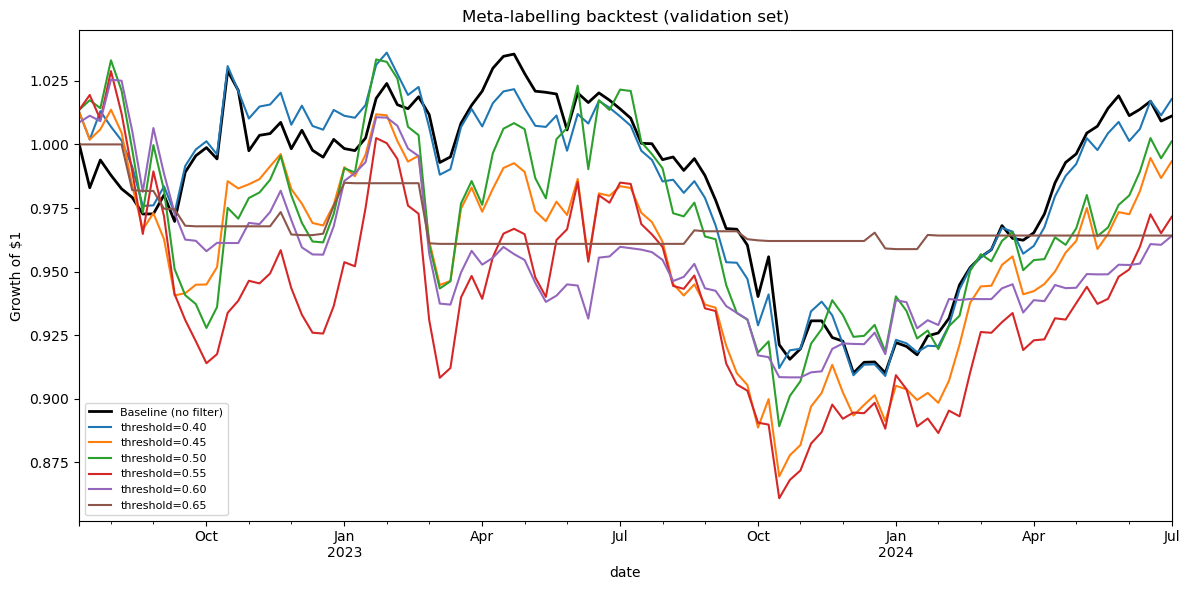


Baseline:
Total return: 1.11%
Sharpe: 0.11
Max drawdown: -12.11%


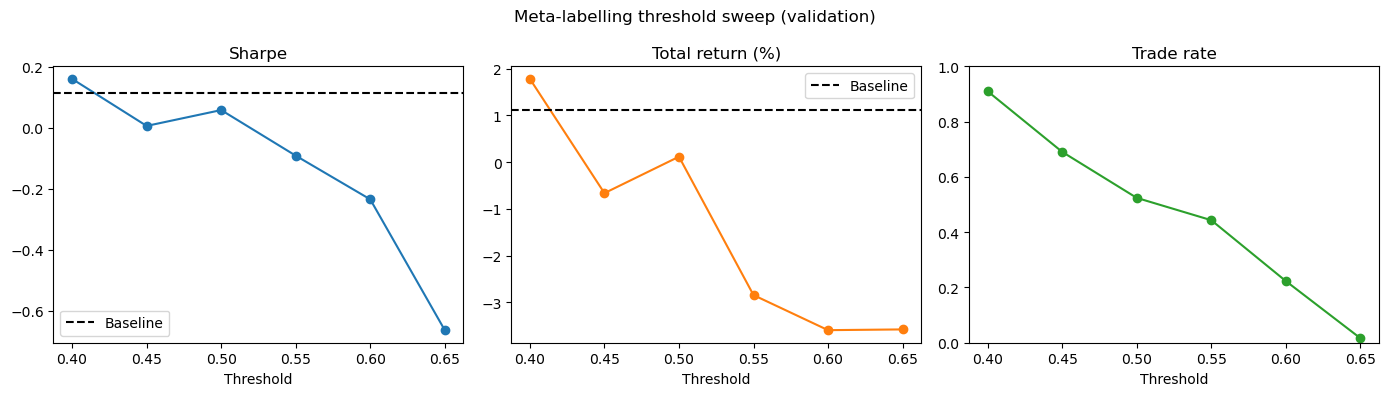

,threshold,trade_rate,total_return_pct,sharpe,max_drawdown_pct
0,0.40,0.909615,1.781336,0.160051,-12.264446
1,0.45,0.690385,-0.664512,0.006036,-14.215926
2,0.50,0.524038,0.115973,0.057955,-13.949752
3,0.55,0.443269,-2.846823,-0.091413,-16.315654
4,0.60,0.223077,-3.597611,-0.234552,-11.412668
5,0.65,0.016346,-3.581728,-0.662930,-4.114981


In [14]:
# Logistic Regression
lr_summary = threshold_backtest(lr_prob_val, 10, thresholds)
lr_summary

##### b. Random Forest

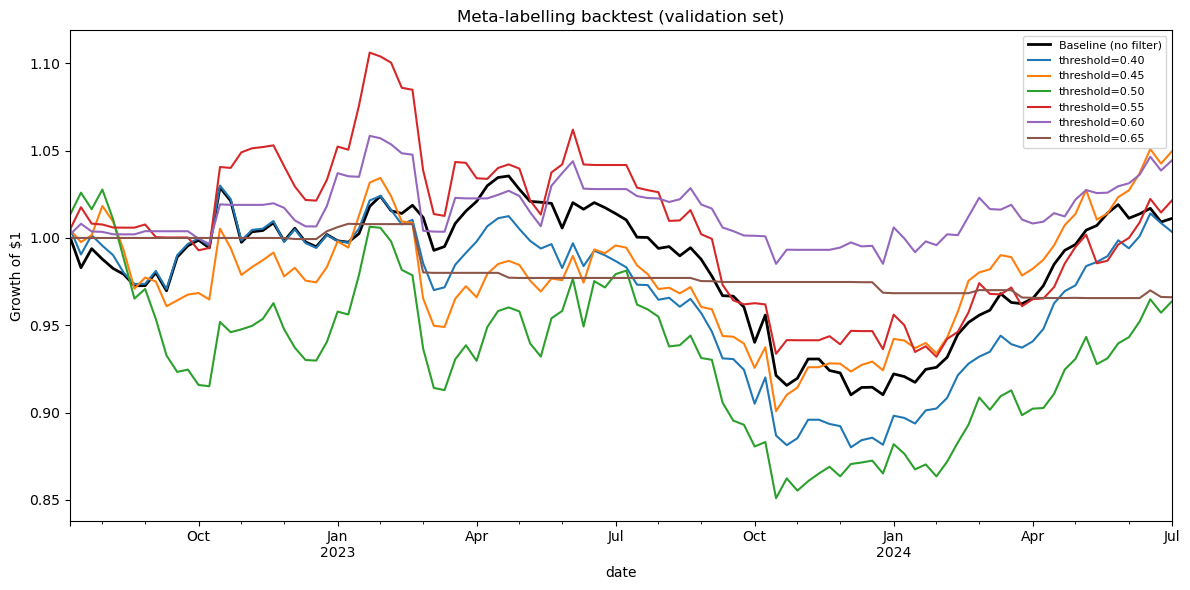


Baseline:
Total return: 1.11%
Sharpe: 0.11
Max drawdown: -12.11%


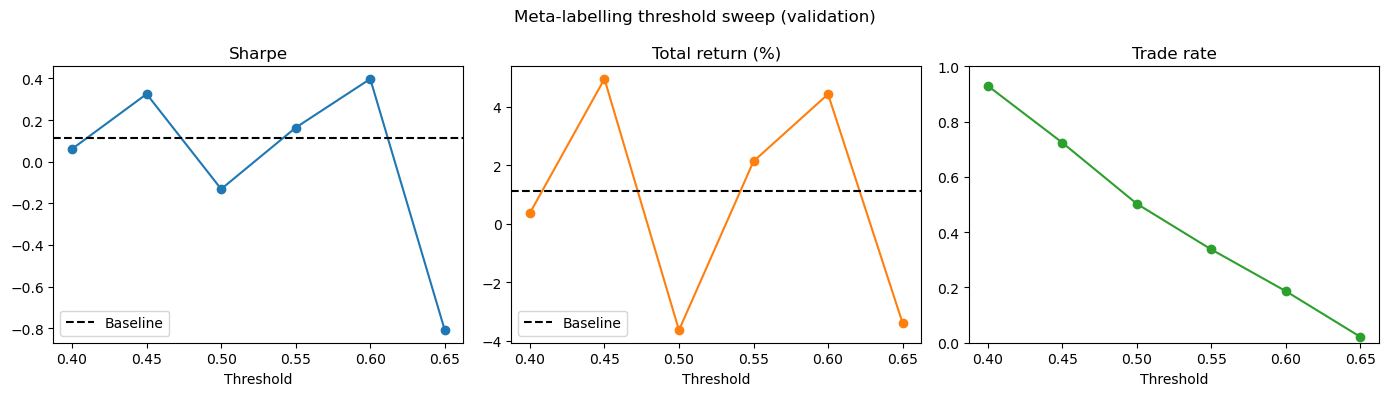

,threshold,trade_rate,total_return_pct,sharpe,max_drawdown_pct
0,0.40,0.929808,0.364501,0.061312,-14.554624
1,0.45,0.724038,4.953382,0.325029,-12.918613
2,0.50,0.502885,-3.641396,-0.131601,-17.204729
3,0.55,0.337500,2.133583,0.163424,-15.748983
4,0.60,0.186538,4.431261,0.397585,-6.925793
5,0.65,0.021154,-3.396175,-0.809497,-4.220232


In [15]:
# Random Forest
rf_summary = threshold_backtest(rf_prob_val, 10, thresholds)
rf_summary

## Conclusion

The model did not yield good resuts. When using machine learning metrics, the model barely outperformed random chance (sometimes it would be worse than random chance). When running the backtest, the random forest did show some improvement over the 0.11 Sharpe ratio, it got a whole 0.4 Sharpe, but that came at a cost of a largest drawdown, and a 0.4 Sharpe ratio is still not very good. Therefore, I will retry the model training phase from scratch in `meta-labelling-v2.ipynb`